# TUTORIAL: ¿CÓMO MEDIR LA CALIDAD DE LOS PRONÓSTICOS EN SERIES DE TIEMPO?

En este tutorial vamos a ver cuáles son las métricas más usadas para medir la calidad de los pronósticos generados por un modelo predictivo en Series de Tiempo. Además veremos los pros y los contras de cada una de estas métricas y las sugerencias de uso

Contenido:
1. ¿Qué es la calidad de los pronósticos y para qué cuantificarla?
2. Las métricas de desempeño más usadas: RMSE, MAE y MAPE
3. ¿Cómo usar las métricas para medir el desempeño de un modelo?

## 1. ¿Qué es la calidad de los pronósticos y para qué cuantificarla?

- Cuando construimos un modelo predictivo para Series de Tiempo lo que nos interesa es saber qué tan buenos o qué tan malos son los pronósticos que genera
- Así que la idea es **cuantificar** de alguna manera el error en los pronósticos
- Si cuantificamos este error en los pronósticos podremos decidir:
    - Si el modelo que estamos implementando es adecuado
    - O si probamos varios modelos cuál de ellos será el más adecuado


Entendamos la idea básica de esta medición de desempeño. Comencemos leyendo el set de datos que contiene el registro histórico (diario) del comportamiento del valor de la acción de Apple durante los últimos años:

In [3]:
# Leer dataset
import pandas as pd
import numpy as np

df = pd.read_csv('accion_apple.csv', parse_dates=['ds'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   unique_id  2514 non-null   object        
 1   ds         2514 non-null   datetime64[ns]
 2   y          2514 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 59.1+ KB


In [4]:
# Split train/test

train = df.iloc[:-365]   # todo menos el último año
test  = df.iloc[-365:]   # último año como prueba
test

,unique_id,ds,y
2149,AAPL,2024-01-16,182.295059
2150,AAPL,2024-01-17,181.351944
2151,AAPL,2024-01-18,187.258667
2152,AAPL,2024-01-19,190.167389
2153,AAPL,2024-01-22,192.480453
...,...,...,...
2509,AAPL,2025-06-24,200.300003
2510,AAPL,2025-06-25,201.559998
2511,AAPL,2025-06-26,201.000000
2512,AAPL,2025-06-27,201.080002


In [5]:
!pip install prophet

In [6]:

# =========================================
# 3) Prophet (solo TRAIN para evaluar en TEST)
# =========================================
from prophet import Prophet
m = Prophet()
m.fit(train.rename(columns={"ds": "ds", "y": "y"}))



21:17:59 - cmdstanpy - INFO - Chain [1] start processing
21:18:00 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
# Construir futuro exactamente con las fechas de TEST
future_test = pd.DataFrame({"ds": test["ds"]})

# Generar predicción SOLO en esas fechas
forecast_test = m.predict(future_test)

# Vector de predicciones alineado a TEST
y_pred = forecast_test["yhat"]
y_pred

0      179.924706
1      180.040988
2      180.037661
3      180.075452
4      180.765416
          ...    
360    211.770075
361    212.005844
362    212.108019
363    212.237174
364    213.118639
Name: yhat, Length: 365, dtype: float64

In [8]:
forecast_test

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-01-16,182.817216,170.379405,189.839409,182.817216,182.817216,-2.892510,-2.892510,-2.892510,-0.668732,-0.668732,-0.668732,-2.223778,-2.223778,-2.223778,0.0,0.0,0.0,179.924706
1,2024-01-17,182.876048,169.334259,189.382038,182.876048,182.876048,-2.835060,-2.835060,-2.835060,-0.623510,-0.623510,-0.623510,-2.211550,-2.211550,-2.211550,0.0,0.0,0.0,180.040988
2,2024-01-18,182.934880,170.592686,190.082879,182.934880,182.934880,-2.897219,-2.897219,-2.897219,-0.722004,-0.722004,-0.722004,-2.175215,-2.175215,-2.175215,0.0,0.0,0.0,180.037661
3,2024-01-19,182.993711,170.748480,189.602122,182.993711,182.993711,-2.918259,-2.918259,-2.918259,-0.803458,-0.803458,-0.803458,-2.114802,-2.114802,-2.114802,0.0,0.0,0.0,180.075452
4,2024-01-22,183.170206,170.786053,190.827175,183.170206,183.170206,-2.404790,-2.404790,-2.404790,-0.609111,-0.609111,-0.609111,-1.795679,-1.795679,-1.795679,0.0,0.0,0.0,180.765416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2025-06-24,213.703809,180.760721,244.755959,184.456958,245.022924,-1.933734,-1.933734,-1.933734,-0.668732,-0.668732,-0.668732,-1.265002,-1.265002,-1.265002,0.0,0.0,0.0,211.770075
361,2025-06-25,213.762641,180.379242,245.264041,184.314607,245.238669,-1.756797,-1.756797,-1.756797,-0.623510,-0.623510,-0.623510,-1.133287,-1.133287,-1.133287,0.0,0.0,0.0,212.005844
362,2025-06-26,213.821473,181.375422,247.272202,184.327448,245.412413,-1.713454,-1.713454,-1.713454,-0.722004,-0.722004,-0.722004,-0.991449,-0.991449,-0.991449,0.0,0.0,0.0,212.108019
363,2025-06-27,213.880304,178.126216,245.538762,184.298876,245.577399,-1.643130,-1.643130,-1.643130,-0.803458,-0.803458,-0.803458,-0.839672,-0.839672,-0.839672,0.0,0.0,0.0,212.237174


In [9]:
# Métricas en TEST
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

y_true = test["y"].values

mae  = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
print(f"Prophet | MAE={mae:.4f} | RMSE={rmse:.4f}")


Prophet | MAE=19.8173 | RMSE=23.6656


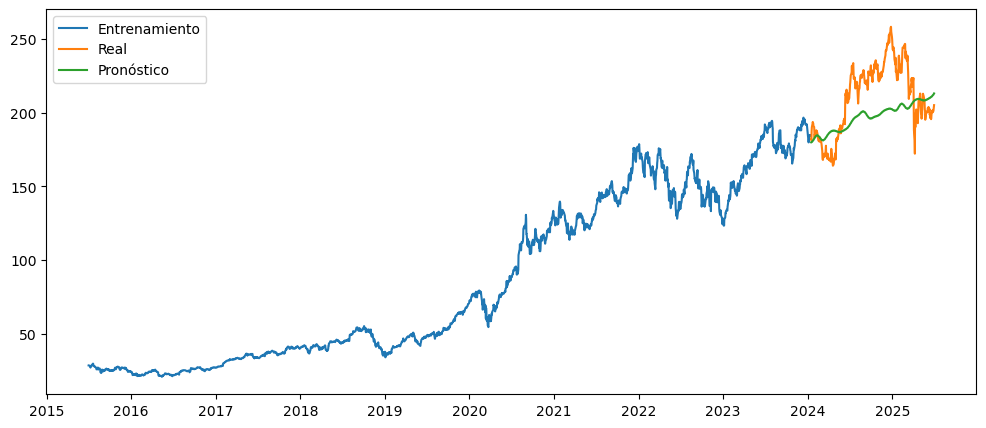

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(train["ds"], train["y"], label="Entrenamiento")
plt.plot(test["ds"], test["y"], label="Real")
plt.plot(test["ds"], y_pred, label="Pronóstico")

plt.legend()
plt.show()


La columna "y" contiene los valores reales de la acción y la columna "prons" contiene los pronósticos realizados por un modelo.

Veamos gráficamente cómo se comparan los valores reales con los pronosticados:

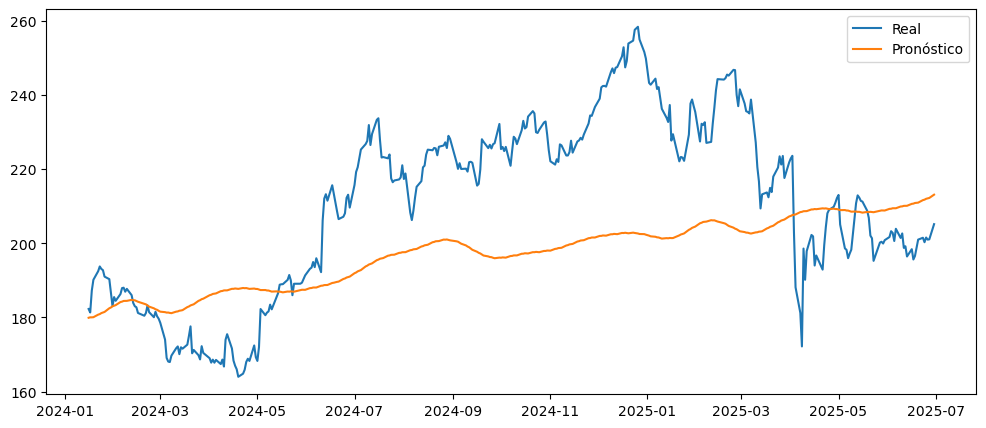

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(test["ds"], test["y"], label="Real")
plt.plot(test["ds"], y_pred, label="Pronóstico")

plt.legend()
plt.show()


Vemos que:

- Los pronósticos siguen "bastante bien" el comportamiento de la Serie original
- Pero en algunos instantes de tiempo la predicción "no es tan buena" pues no logra capturar variaciones rápidas en la Serie original

La idea es que no seamos subjetivos al evaluar el desempeño del modelo y que usemos algunas métricas para cuantificar dicho desempeño.

## 2. Las métricas de desempeño más usadas: RMSE, MAE y MAPE

Aunque hay múltiples métricas, las más usadas son convencionalmente RMSE, MAE y MAPE.

Veamos en detalle cada una de estas métricas, así como su forma de cálculo y sus ventajas y desventajas.

### 2.1. Raíz cuadrada del error cuadrático medio (*RMSE: root mean squared error*)

Si $N$ es la cantidad de datos que tiene la Serie, $y_t$ es la observación (valor conocido) en cada instante de tiempo y $\hat{y}_t$ es el pronóstico correspondiente, entonces:

$$\text{RMSE} = \sqrt{\frac {\sum_{t=1}^{n} \left( y_t - \hat{y}_t \right)^2}{N}}$$

Algunas características, ventajas y desventajas de esta métrica:
- Es dependiente de la escala: **la métrica está en la misma escala de las observaciones originales**
- ✅ Es fácil de interpretar (precisamente porque está en la misma escala de los datos originales)
- ❌ Es sensible a valores extremos, pues el error cuadrático "amplifica" las diferencias (aunque esto puede ser visto como una ventaja)

Calculemos el RMSE para los pronósticos anteriores:

In [12]:
y=y_true
y_pred=y_pred

mse=np.mean((y - y_pred)**2)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f} USD  (MSE: {mse:.2f} USD2)")

RMSE: 23.67 USD  (MSE: 560.06 USD2)


¿Este valor corresponde a un desempeño adecuado o no?

- Se debe comparar con el rango de valores de la Serie original:
    - Así, la Serie original tiene valores cercanos a los 225 USD y el error que se tiene en el pronóstico es del orden de 8.46.
    - Y por tanto este error representa aproximadamente un 3.8% de la escala original de la Serie
- Preguntas que deberíamos responder:
    - ¿Estamos dispuestos a aceptar un error de esta magnitud en nuestro proyecto?
    - ¿Existe algún modelo que genere un menor error?

### 2.2. Error absoluto medio (*MAE: mean absolute error*)

En este caso el error se calcula como:

$$\text{MAE} = \frac{\sum_{t=1}^{n} | y_t - \hat{y}_t |}{N}$$

Algunas características, ventajas y desventajas de esta métrica:
- Es dependiente de la escala: **la métrica está en la misma escala de las observaciones originales**
- ✅ Es fácil de interpretar (precisamente porque está en la misma escala de los datos originales)
- ✅ Es menos sensible a valores extremos en comparación con el RMSE (aunque esto puede ser visto como una desventaja)
    - ❌ Puede indicar un desempeño más optimista que el obtenido con el RMSE

Calculemos el MAE para los pronósticos anteriores:

In [13]:
mae = np.mean(np.abs(y - y_pred))
print(f"MAE: {mae:.2f} USD")

MAE: 19.82 USD


Recordemos que el RMSE fue de 8.46 USD. Esto se debe a que la primera métrica es sensible a valores extremos (los cuales están precisamente en la Serie original).

En este caso, estos 5.35 USD representan un 5.35/225 = 2.4% de la escala original de la Serie. De nuevo, debemos preguntarnos:

- ¿Estamos dispuestos a aceptar un error de esta magnitud en nuestro proyecto?
- ¿Existe algún modelo que genere un menor error?

### 2.3. Error porcentual absoluto medio (*MAPE: mean absolute percentage error*)

En este caso el error se calcula como:

$$\text{MAPE} = \frac{100}{n} \sum_{t=1}^{n} \left| \frac{y_t - \hat{y}_t}{y_t} \right|$$


Algunas características, ventajas y desventajas de esta métrica:
- Es **independiente de la escala: la métrica se mide como un porcentaje
- ✅ Es fácil de interpretar: 0% → mejor desempeño, 100% o más → desempeño "terrible"
- ✅ Es menos sensible a valores extremos en comparación con el RMSE
- ❌ No es adecuada si la serie original contiene valores iguales o muy cercanos a cero

Calculemos el MAPE para los pronósticos anteriores:

In [14]:
mape = np.mean(np.abs((y - y_pred) / y)) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 9.04%


Lo cual quiere decir que, en promedio, el modelo genera pronósticos que se alejan en un 2.54% del valor real de la Serie.

Al igual que en los casos anteriores, debemos preguntarnos:

- ¿Estamos dispuestos a aceptar un error de esta magnitud en nuestro proyecto?
- ¿Existe algún modelo que genere un menor error?

# Para la Guía Autónoma

Desarrollar el modelamiento (y validación) con los datos de tu proyecto, en caso de no ser el tipo de objetivo/problema, debes desarrollar con un dataset de kaggle o de otra fuente. 
Seguir los pasos del cuaderno de la guía práctica pero usar otros datos o datos actualizados de
https://es.investing.com/equities/apple-computer-inc-historical-data 

In [15]:
# fin del cuaderno

Para evaluación (backtest/test set) → se usa future_test = test[["ds"]].

Para pronóstico futuro real → se usa make_future_dataframe con periods y freq, porque ahí no tienes un test.

# Bonus (para los que están haciendo ST)

### Predecir a futuro

In [19]:
# =========================================
# 4) FUTURO con Prophet (reentrena con TODO el histórico)
#    -> así garantizamos que el horizonte empiece DESPUÉS del último día real
# =========================================
# Inferir frecuencia (si no se puede, asumimos bursátil 'B') 
FREQ = pd.infer_freq(df["ds"].sort_values()) or "B" 
print(f"FREQ: {FREQ}")

'''
m.fit(train.rename(columns={"ds": "ds", "y": "y"}))

# Pronóstico hasta el fin de TEST, freq="D": define la frecuencia diaria. Si tus datos son bursátiles (días hábiles), podrías usar "B"
future_test = m.make_future_dataframe(periods=len(test), freq="D")
forecast_test = m.predict(future_test)
'''
# Para pronosticar hacia el futuro real (más allá del último día histórico df["ds"].max()), conviene aprovechar TODA la información disponible.
m_full = Prophet()
m_full.fit(df.rename(columns={"ds": "ds", "y": "y"})) 

HORIZON_FUTURO = 7   # <-- cámbialo a 15 o 30 cuando quieras

# make_future_dataframe agrega 'periods' más allá del último ds del entrenamiento completo
future_full = m_full.make_future_dataframe(periods=HORIZON_FUTURO, freq=FREQ)
forecast_full = m_full.predict(future_full)
forecast_full


21:19:54 - cmdstanpy - INFO - Chain [1] start processing


FREQ: B


21:19:54 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-07-01,22.798881,9.263137,31.781285,22.798881,22.798881,-2.003862,-2.003862,-2.003862,-1.098115,-1.098115,-1.098115,-0.905746,-0.905746,-0.905746,0.0,0.0,0.0,20.795019
1,2015-07-02,22.807612,9.642148,33.103223,22.807612,22.807612,-1.598086,-1.598086,-1.598086,-1.146798,-1.146798,-1.146798,-0.451288,-0.451288,-0.451288,0.0,0.0,0.0,21.209526
2,2015-07-06,22.842537,11.610855,34.709245,22.842537,22.842537,0.380807,0.380807,0.380807,-0.981035,-0.981035,-0.981035,1.361842,1.361842,1.361842,0.0,0.0,0.0,23.223344
3,2015-07-07,22.851269,12.869373,34.757266,22.851269,22.851269,0.784582,0.784582,0.784582,-1.008481,-1.008481,-1.008481,1.793063,1.793063,1.793063,0.0,0.0,0.0,23.635851
4,2015-07-08,22.860000,12.042275,35.372323,22.860000,22.860000,1.109007,1.109007,1.109007,-1.098115,-1.098115,-1.098115,2.207123,2.207123,2.207123,0.0,0.0,0.0,23.969008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2516,2025-07-03,234.804911,222.315885,244.888312,234.804911,234.804911,-0.910852,-0.910852,-0.910852,-1.146798,-1.146798,-1.146798,0.235946,0.235946,0.235946,0.0,0.0,0.0,233.894059
2517,2025-07-04,234.887908,223.511983,246.016825,234.887908,234.887908,-0.467840,-0.467840,-0.467840,-1.159702,-1.159702,-1.159702,0.691862,0.691862,0.691862,0.0,0.0,0.0,234.420068
2518,2025-07-07,235.136899,224.769979,247.224855,235.136899,235.136899,1.021453,1.021453,1.021453,-0.981035,-0.981035,-0.981035,2.002488,2.002488,2.002488,0.0,0.0,0.0,236.158353
2519,2025-07-08,235.219897,225.239981,247.358504,235.219897,235.219897,1.398002,1.398002,1.398002,-1.008481,-1.008481,-1.008481,2.406483,2.406483,2.406483,0.0,0.0,0.0,236.617899


In [20]:
# Fechas de referencia
cut_date   = df["ds"].max()          # último día real
test_start = test["ds"].min()        # inicio del periodo de test
cut_date, test_start

(Timestamp('2025-06-30 00:00:00'), Timestamp('2024-01-16 00:00:00'))

In [21]:
# =========================================
# A) TEST: real vs predicho (alineado por fecha)
# =========================================

y_true = test["y"].values

# Alinea forecast_test con las fechas de test para evitar desorden por índices
#pred_test_df = forecast_test.merge(test[["ds"]], on="ds", how="right")
#y_pred = pred_test_df["yhat"].values
y_pred = forecast_test.iloc[-len(test):]["yhat"].values

tabla_test = pd.DataFrame({
    "ds": test["ds"].values,
    "y_true": y_true,
    "y_pred": y_pred,
    "tipo": "test"
})
tabla_test

,ds,y_true,y_pred,tipo
0,2024-01-16,182.295059,179.924706,test
1,2024-01-17,181.351944,180.040988,test
2,2024-01-18,187.258667,180.037661,test
3,2024-01-19,190.167389,180.075452,test
4,2024-01-22,192.480453,180.765416,test
...,...,...,...,...
360,2025-06-24,200.300003,211.770075,test
361,2025-06-25,201.559998,212.005844,test
362,2025-06-26,201.000000,212.108019,test
363,2025-06-27,201.080002,212.237174,test


In [22]:
# =========================================
# B) FUTURO: HORIZON_FUTURO días desde el último ds real
# =========================================
# HORIZON_FUTURO = 7   # <-- cambia a 15 o 30 cuando quieras

# 'forecast_full' contiene historia + futuro; nos quedamos SOLO con el tramo futuro
tabla_futuro = (
    forecast_full[forecast_full["ds"] > cut_date]
      .head(HORIZON_FUTURO)[["ds","yhat"]]
      .rename(columns={"yhat": "y_pred"})
      .assign(tipo="futuro", y_true=np.nan)
)
tabla_futuro

,ds,y_pred,tipo,y_true
2514,2025-07-01,232.951220,futuro,NaN
2515,2025-07-02,233.401347,futuro,NaN
2516,2025-07-03,233.894059,futuro,NaN
2517,2025-07-04,234.420068,futuro,NaN
2518,2025-07-07,236.158353,futuro,NaN
2519,2025-07-08,236.617899,futuro,NaN
2520,2025-07-09,236.992324,futuro,NaN


In [23]:
# =========================================
# C) UNIFICAR: test + futuro  -> tabla_unificada
# =========================================
pred_total_prophet = pd.concat(
    [tabla_test[["ds","y_pred","tipo","y_true"]],
     tabla_futuro[["ds","y_pred","tipo","y_true"]]],
    ignore_index=True
)

# Agregar y_true de todo el histórico (por si lo necesitas en ventanas de zoom)
real_all = df[["ds","y"]].rename(columns={"y": "y_true"})
tabla_unificada = (
    pred_total_prophet
      .merge(real_all, on="ds", how="left", suffixes=("", "_real"))
)
# Prioriza el y_true ya presente (test); completa con y_true_real donde sea NaN (futuro)
tabla_unificada["y_true"] = tabla_unificada["y_true"].fillna(tabla_unificada["y_true_real"])
tabla_unificada = (
    tabla_unificada
      .drop(columns=["y_true_real"])
      .sort_values("ds")
      .reset_index(drop=True)
)

# Revisa el cierre de test + los HORIZON_FUTURO días futuros
tabla_unificada.tail(HORIZON_FUTURO + 10)


,ds,y_pred,tipo,y_true
355,2025-06-16,210.643109,test,198.419998
356,2025-06-17,210.703600,test,195.639999
357,2025-06-18,210.875672,test,196.580002
358,2025-06-20,210.972585,test,201.000000
359,2025-06-23,211.649297,test,201.500000
360,2025-06-24,211.770075,test,200.300003
361,2025-06-25,212.005844,test,201.559998
362,2025-06-26,212.108019,test,201.000000
363,2025-06-27,212.237174,test,201.080002
364,2025-06-30,213.118639,test,205.169998


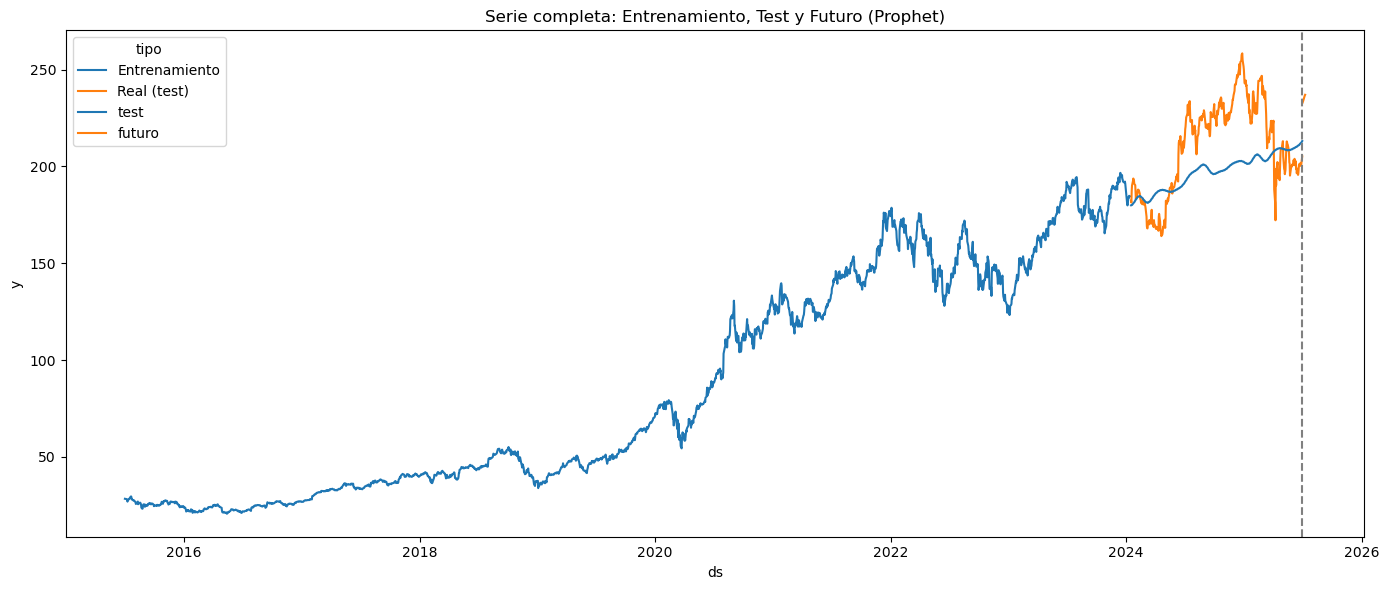

In [24]:
# GLOBAL: train + real(test) + pronóstico(test/futuro)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.lineplot(data=df[df["ds"] < test["ds"].min()], x="ds", y="y", label="Entrenamiento")
sns.lineplot(data=df[df["ds"] >= test["ds"].min()], x="ds", y="y", label="Real (test)")
sns.lineplot(data=tabla_unificada, x="ds", y="y_pred", hue="tipo")  # test/futuro
plt.axvline(cut_date, color="gray", linestyle="--")
plt.title("Serie completa: Entrenamiento, Test y Futuro (Prophet)")
plt.tight_layout(); plt.show()


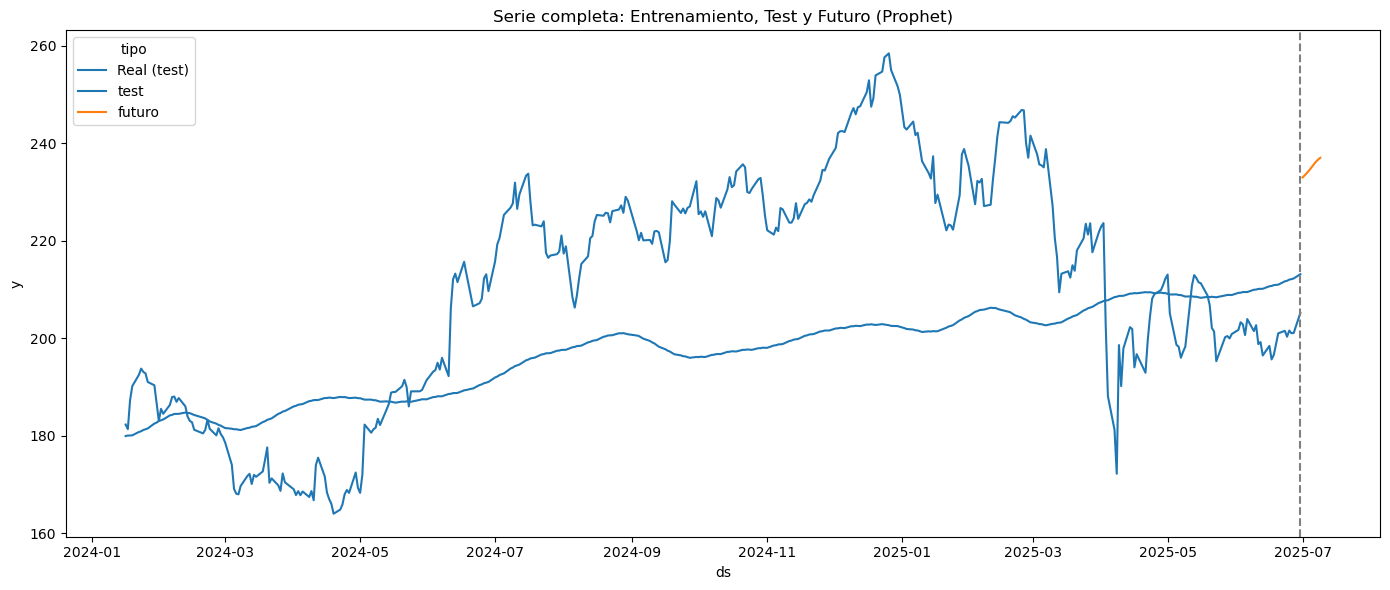

In [25]:
# GLOBAL: train + real(test) + pronóstico(test/futuro)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.lineplot(data=df[df["ds"] >= test["ds"].min()], x="ds", y="y", label="Real (test)")
sns.lineplot(data=tabla_unificada, x="ds", y="y_pred", hue="tipo")  # test/futuro
plt.axvline(cut_date, color="gray", linestyle="--")
plt.title("Serie completa: Entrenamiento, Test y Futuro (Prophet)")
plt.tight_layout(); plt.show()

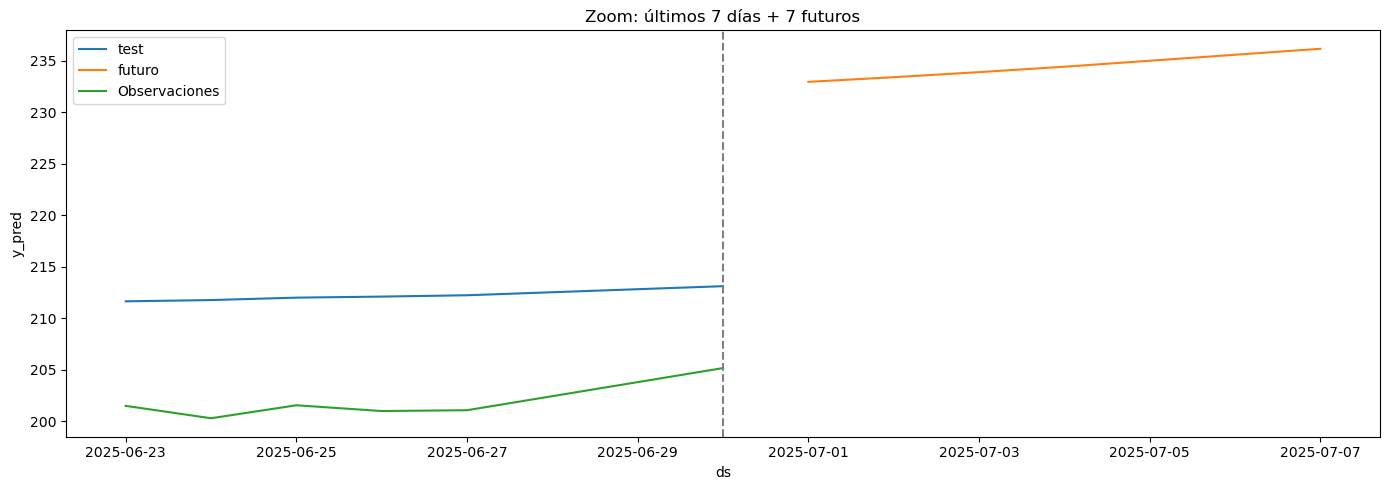

,ds,y_pred,tipo,y_true
359,2025-06-23,211.649297,test,201.500000
360,2025-06-24,211.770075,test,200.300003
361,2025-06-25,212.005844,test,201.559998
362,2025-06-26,212.108019,test,201.000000
363,2025-06-27,212.237174,test,201.080002
364,2025-06-30,213.118639,test,205.169998
365,2025-07-01,232.951220,futuro,NaN
366,2025-07-02,233.401347,futuro,NaN
367,2025-07-03,233.894059,futuro,NaN
368,2025-07-04,234.420068,futuro,NaN


In [26]:
# ZOOM: últimos 30 días + 7/15/30 futuros (ajusta pasado_dias / futuro_dias)
def plot_zoom(tabla, df, pasado_dias=30, futuro_dias=7):
    cut = df["ds"].max()
    ini = cut - pd.Timedelta(days=int(pasado_dias))
    fin = cut + pd.Timedelta(days=int(futuro_dias))
    sub = tabla[(tabla["ds"] >= ini) & (tabla["ds"] <= fin)]

    plt.figure(figsize=(14,5))
    sns.lineplot(data=sub, x="ds", y="y_pred", hue="tipo")
    sns.lineplot(data=sub[sub["y_true"].notna()], x="ds", y="y_true", label="Observaciones")
    plt.axvline(cut, color="gray", linestyle="--")
    plt.title(f"Zoom: últimos {pasado_dias} días + {futuro_dias} futuros")
    plt.tight_layout(); plt.show()
    return sub


plot_zoom(tabla_unificada, df, pasado_dias=7, futuro_dias=HORIZON_FUTURO)


In [27]:
print("FREQ inferida:", pd.infer_freq(df["ds"].sort_values()))
print("\nÚltimas 10 fechas de test:")
print(test["ds"].tail(10).to_list())
print("\nÚltimas 10 fechas de forecast_test:")
print(forecast_test["ds"].tail(10).to_list())


FREQ inferida: None

Últimas 10 fechas de test:
[Timestamp('2025-06-16 00:00:00'), Timestamp('2025-06-17 00:00:00'), Timestamp('2025-06-18 00:00:00'), Timestamp('2025-06-20 00:00:00'), Timestamp('2025-06-23 00:00:00'), Timestamp('2025-06-24 00:00:00'), Timestamp('2025-06-25 00:00:00'), Timestamp('2025-06-26 00:00:00'), Timestamp('2025-06-27 00:00:00'), Timestamp('2025-06-30 00:00:00')]

Últimas 10 fechas de forecast_test:
[Timestamp('2025-06-16 00:00:00'), Timestamp('2025-06-17 00:00:00'), Timestamp('2025-06-18 00:00:00'), Timestamp('2025-06-20 00:00:00'), Timestamp('2025-06-23 00:00:00'), Timestamp('2025-06-24 00:00:00'), Timestamp('2025-06-25 00:00:00'), Timestamp('2025-06-26 00:00:00'), Timestamp('2025-06-27 00:00:00'), Timestamp('2025-06-30 00:00:00')]


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Holt-Winters | MAE=20.3306 | RMSE=24.1321


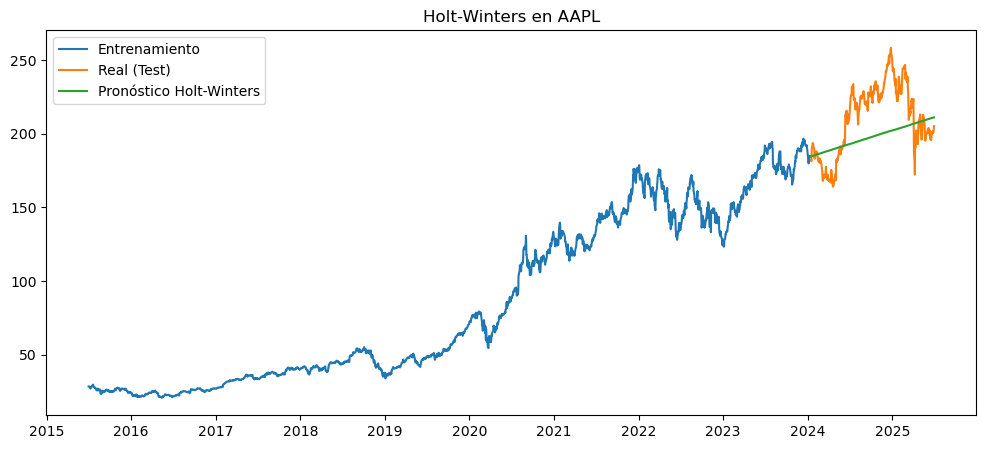

In [28]:
# =========================================
# Holt-Winters (Exponential Smoothing, ETS)
# =========================================
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Serie de entrenamiento como Serie temporal
y_train = train.set_index("ds")["y"]

# Periodicidad: para bursátil se suele usar ~252 días/año
seasonal_periods = 252

# Entrenar modelo simple (tendencia aditiva, sin estacionalidad fuerte en precios)
hw_model = ExponentialSmoothing(
    y_train,
    trend="add",           # "add" o "mul"
    seasonal=None,         # puedes probar "add" con seasonal_periods=252
    seasonal_periods=None
).fit(optimized=True)

# Pronóstico en el horizonte de TEST
yhat_hw_test = hw_model.forecast(len(test))
yhat_hw_test.index = test["ds"]  # alinear con fechas de TEST

# Métricas
mae_hw  = mean_absolute_error(test["y"], yhat_hw_test)
rmse_hw = root_mean_squared_error(test["y"], yhat_hw_test)
print(f"Holt-Winters | MAE={mae_hw:.4f} | RMSE={rmse_hw:.4f}")

# ===============================
# Gráfico comparativo
# ===============================
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(train["ds"], train["y"], label="Entrenamiento")
plt.plot(test["ds"], test["y"], label="Real (Test)")
plt.plot(test["ds"], yhat_hw_test, label="Pronóstico Holt-Winters")
plt.legend()
plt.title("Holt-Winters en AAPL")
plt.show()


In [29]:
# =========================================
# 4) FUTURO con Holt-Winters (reentrena con TODO el histórico)
# =========================================
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pandas.tseries.frequencies import to_offset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Serie completa para entrenar ETS
y_full = df.set_index("ds")["y"]

# Modelo ETS simple (tendencia aditiva, sin estacionalidad para precios)
hw_model_full = ExponentialSmoothing(
    y_full,
    trend="add",
    seasonal=None,
    seasonal_periods=None
).fit(optimized=True)

# Índice futuro exactamente en el calendario elegido
step = (pd.offsets.BDay() if str(FREQ).upper().startswith("B") else to_offset(FREQ))
last_real = df["ds"].max()
future_idx_hw = (
    pd.bdate_range(start=last_real + step, periods=HORIZON_FUTURO)
    if str(FREQ).upper().startswith("B")
    else pd.date_range(start=last_real + step, periods=HORIZON_FUTURO, freq=FREQ)
)

# Pronóstico a futuro
yhat_hw_future = hw_model_full.forecast(HORIZON_FUTURO)
yhat_hw_future.index = future_idx_hw  # alineamos fechas

# Tabla FUTURO (HW)
tabla_futuro_hw = (
    yhat_hw_future.rename("y_pred").to_frame().reset_index()
        .rename(columns={"index": "ds"})
        .assign(tipo="futuro_HW", y_true=np.nan)
)
tabla_futuro_hw.head()


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,ds,y_pred,tipo,y_true
0,2025-07-01,205.221745,futuro_HW,NaN
1,2025-07-02,205.292097,futuro_HW,NaN
2,2025-07-03,205.362450,futuro_HW,NaN
3,2025-07-04,205.432803,futuro_HW,NaN
4,2025-07-07,205.503156,futuro_HW,NaN


In [31]:
# =========================================
# 4.1) (Opcional) TEST con HW para comparar (por si no lo creaste antes)
# =========================================
# Si ya tienes yhat_hw_test, puedes saltarte este bloque.
y_train = train.set_index("ds")["y"]
hw_model_test = ExponentialSmoothing(
    y_train, trend="add", seasonal=None, seasonal_periods=None
).fit(optimized=True)

yhat_hw_test = hw_model_test.forecast(len(test))
yhat_hw_test.index = test["ds"]

tabla_test_hw = pd.DataFrame({
    "ds": test["ds"].values,
    "y_pred": yhat_hw_test.values,
    "tipo": "test_HW",
    "y_true": test["y"].values
})


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [32]:
# =========================================
# 4.2) UNIFICAR (HW): test + futuro -> tabla_unificada_hw
# =========================================
pred_total_hw = pd.concat(
    [tabla_test_hw[["ds","y_pred","tipo","y_true"]],
     tabla_futuro_hw[["ds","y_pred","tipo","y_true"]]],
    ignore_index=True
)

real_all = df[["ds","y"]].rename(columns={"y": "y_true"})
tabla_unificada_hw = (
    pred_total_hw.merge(real_all, on="ds", how="left", suffixes=("", "_real"))
)
tabla_unificada_hw["y_true"] = tabla_unificada_hw["y_true"].fillna(tabla_unificada_hw["y_true_real"])
tabla_unificada_hw = (
    tabla_unificada_hw.drop(columns=["y_true_real"])
                      .sort_values("ds").reset_index(drop=True)
)

# Revisa cierre + HORIZON_FUTURO
tabla_unificada_hw.tail(HORIZON_FUTURO + 10)


,ds,y_pred,tipo,y_true
355,2025-06-16,210.448414,test_HW,198.419998
356,2025-06-17,210.521135,test_HW,195.639999
357,2025-06-18,210.593856,test_HW,196.580002
358,2025-06-20,210.666576,test_HW,201.000000
359,2025-06-23,210.739297,test_HW,201.500000
360,2025-06-24,210.812018,test_HW,200.300003
361,2025-06-25,210.884738,test_HW,201.559998
362,2025-06-26,210.957459,test_HW,201.000000
363,2025-06-27,211.030180,test_HW,201.080002
364,2025-06-30,211.102901,test_HW,205.169998


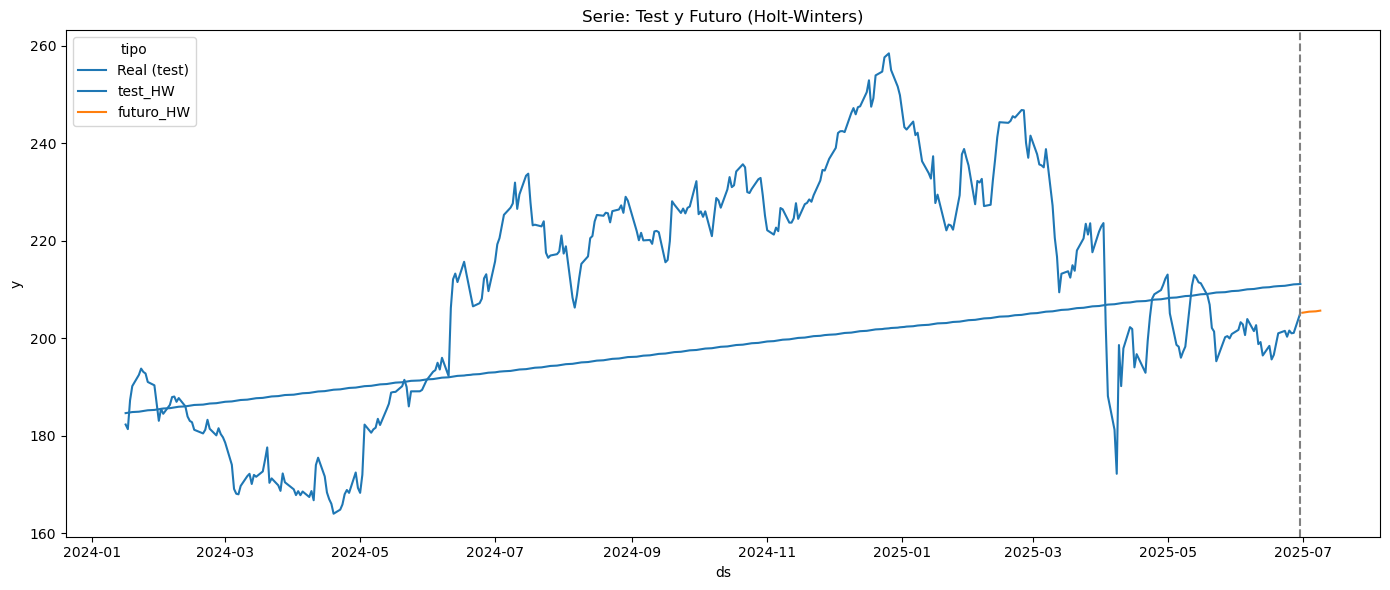

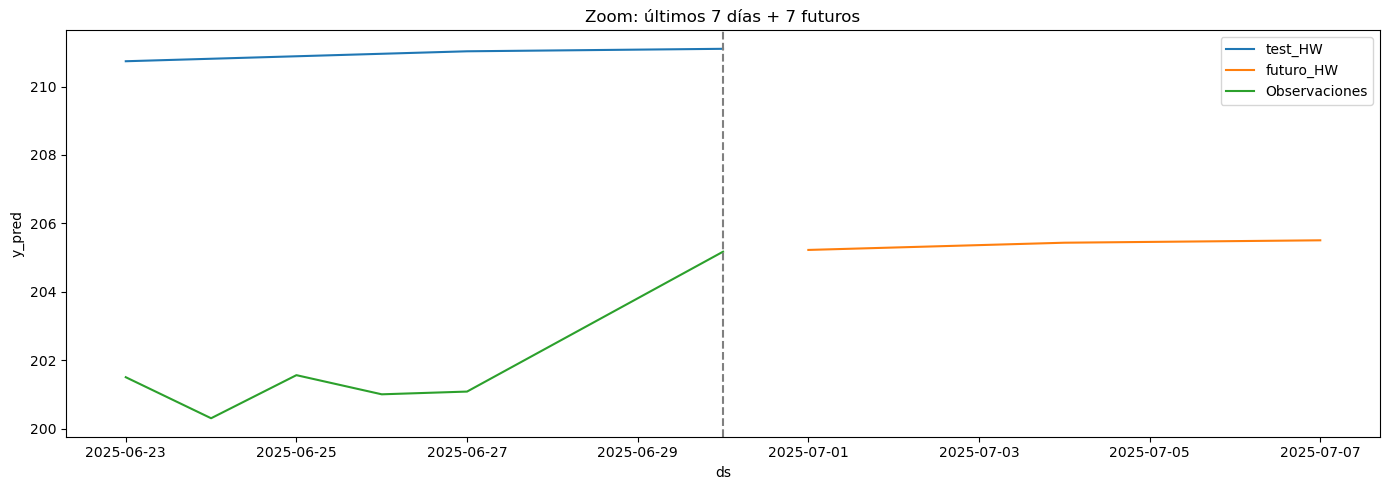

,ds,y_pred,tipo,y_true
359,2025-06-23,210.739297,test_HW,201.500000
360,2025-06-24,210.812018,test_HW,200.300003
361,2025-06-25,210.884738,test_HW,201.559998
362,2025-06-26,210.957459,test_HW,201.000000
363,2025-06-27,211.030180,test_HW,201.080002
364,2025-06-30,211.102901,test_HW,205.169998
365,2025-07-01,205.221745,futuro_HW,NaN
366,2025-07-02,205.292097,futuro_HW,NaN
367,2025-07-03,205.362450,futuro_HW,NaN
368,2025-07-04,205.432803,futuro_HW,NaN


In [33]:
# =========================================
# 4.3) GRÁFICOS (HW): global y zoom, análogos a Prophet
# =========================================
cut_date = df["ds"].max()

plt.figure(figsize=(14,6))
sns.lineplot(data=df[df["ds"] >= test["ds"].min()], x="ds", y="y", label="Real (test)")
sns.lineplot(data=tabla_unificada_hw, x="ds", y="y_pred", hue="tipo")  # test_HW / futuro_HW
plt.axvline(cut_date, color="gray", linestyle="--")
plt.title("Serie: Test y Futuro (Holt-Winters)")
plt.tight_layout(); plt.show()

# Reutiliza tu misma función de zoom
plot_zoom(tabla_unificada_hw, df, pasado_dias=7, futuro_dias=HORIZON_FUTURO)
